# IMPORT E DEFINIÇÕES NECESSÁRIAS

In [1]:
import pandas as pd
import hashlib
import random
import uuid
from datetime import datetime, timedelta

import sys
!{sys.executable} -m pip install faker

from faker import Faker

fake = Faker()
print(fake.name())


[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Edward Franklin


In [2]:
fake = Faker("pt_BR")
random.seed(21)

# FUNÇÕES

In [3]:
def hash_senha(senha: str) -> str:
    return hashlib.sha256(senha.encode()).hexdigest()

def data_aleatoria(inicio: datetime, fim: datetime) -> datetime:
    delta = fim - inicio
    return inicio + timedelta(seconds=random.randint(0, int(delta.total_seconds())))

def rotular_sentimento(titulo: str) -> str:
    tokens = set(titulo.lower().split())
    if tokens & PALAVRAS_URGENTE:
        return "urgente"
    if tokens & PALAVRAS_NEGATIVO:
        return "negativo"
    if tokens & PALAVRAS_POSITIVO:
        return "positivo"
    return "neutro"

def gerar_descricao_thread(tipo: str, tema: str, municipio: str) -> str:
    template = random.choice(DESCRICOES_THREAD)
    return template.format(tipo=tipo.lower(), tema=tema.lower(), municipio=municipio)

def rotular_sentimento_post(tipo: str, conteudo: str) -> str:
    tokens = set(conteudo.lower().split())
    pool   = SENTIMENTOS_POST[tipo]
    if tokens & {"urgente", "grave", "imediato", "crise"}:
        return "urgente"
    return random.choice(pool)

def gerar_conteudo_post(tipo: str, tema: str) -> str:
    templates = {
        "contribuicao": [
            f"Apoio esta proposta sobre {tema}. Acredito que pode trazer benefícios reais para a população.",
            f"Tenho experiência com {tema} e posso afirmar que essa iniciativa vai na direção certa.",
        ],
        "contraproposta": [
            f"Discordo parcialmente. Em vez disso, poderíamos abordar {tema} com uma estratégia mais gradual.",
            f"A proposta ignora aspectos importantes de {tema}. Sugiro revisão antes de avançar.",
        ],
        "comentario": [
            f"Interessante perspectiva sobre {tema}. Já vimos iniciativas similares em outros contextos.",
            f"Precisamos de mais dados antes de tomar decisões sobre {tema}.",
        ],
        "esclarecimento": [
            f"Para esclarecer: a proposta sobre {tema} não implica aumento de custos imediato.",
            f"Alguns pontos sobre {tema} foram mal interpretados. Deixo aqui a explicação correta.",
        ],
    }
    return random.choice(templates[tipo])


# BASE USUÁRIOS

In [4]:


REGIOES_BR = [
    "AC","AL","AP","AM","BA","CE","DF","ES","GO",
    "MA","MT","MS","MG","PA","PB","PR","PE","PI",
    "RJ","RN","RS","RO","RR","SC","SP","SE","TO"
]

SETORES_EMPRESA = [
    "Tecnologia","Saúde","Educação","Varejo","Financeiro",
    "Logística","Agronegócio","Energia","Construção","Serviços"
]

inicio_data = datetime(2023, 1, 1)
fim_data    = datetime(2025, 12, 31)

registros = []
for _ in range(70_000):
    sexo     = random.choice(["M", "F", "NB"])
    nome     = fake.name_male() if sexo == "M" else fake.name_female() if sexo == "F" else fake.name()
    segmento = random.choice(["civico", "empresarial", "ambos"])

    registros.append({
        "id":         str(uuid.uuid4()),
        "nome":       nome,
        "idade":      random.randint(18, 75),
        "sexo":       sexo,
        "email":      fake.email(),
        "telefone":   fake.cellphone_number(),
        "usuario":    fake.user_name() + str(random.randint(1, 999)),
        "senha_hash": hash_senha(fake.password()),
        "regiao":     random.choice(REGIOES_BR),
        "municipio":  fake.city(),
        "segmento":   segmento,
        "setor":      random.choice(SETORES_EMPRESA) if segmento in ["empresarial", "ambos"] else None,
        "tenant_id":  str(uuid.uuid4()) if segmento in ["empresarial", "ambos"] else "publico",
        "criado_em":  data_aleatoria(inicio_data, fim_data),
        "ativo":      random.choices([True, False], weights=[90, 10])[0],
        "verificado": random.choices([True, False], weights=[70, 30])[0],
    })

df_usuarios = pd.DataFrame(registros)

df_usuarios["criado_em"] = pd.to_datetime(df_usuarios["criado_em"])
df_usuarios["idade"]     = df_usuarios["idade"].astype("int8")
df_usuarios["ativo"]     = df_usuarios["ativo"].astype(bool)
df_usuarios["verificado"]= df_usuarios["verificado"].astype(bool)

In [5]:
df_usuarios

,id,nome,idade,sexo,email,telefone,usuario,senha_hash,regiao,municipio,segmento,setor,tenant_id,criado_em,ativo,verificado
0,963837f2-2221-434b-8cdc-669e4345f3ff,Matteo Cunha,62,M,melissalopes@example.net,+55 (81) 9 9214-2130,theocamara429,f1bcdabf6d8808c0a453e82ce9541b895e214be98396d2...,RS,Borges,empresarial,Financeiro,cebc047b-22b7-4df7-af03-80a93d8b7213,2025-01-14 06:09:36,True,False
1,6d8c119a-e019-4c43-98f6-a2c5a86d0480,Mariana Câmara,29,F,santosisaque@example.org,+55 (46) 90185-6824,cecilia01518,f0d46d0a02dffec1be59f1336199f969dd5575f07fc906...,PE,Costela da Serra,ambos,Varejo,be226f88-00f3-4cab-ab07-9204b308242a,2023-01-05 22:34:57,True,False
2,bbc75cdc-af22-47e3-a3bc-ab9c040009f4,Ana Julia Alves,27,F,aliciasouza@example.net,+55 71 96927-6439,tsilva813,16a03a3eb871b1628368c0bcb65d967f63c90955c8fbd9...,SP,Barbosa,civico,NaN,publico,2023-12-27 19:00:31,False,True
3,cc203ae8-cea8-421e-a974-7a3a1016bb2a,Allana Abreu,67,F,joao-guilhermeda-luz@example.net,+55 (57) 9 0361-9057,cavalcantemaria-liz897,ee5cde17d375ae9c671368f50a191a63a57c462df3a7d4...,PA,Porto de Teixeira,ambos,Serviços,4b465b72-fa5f-4fcf-a366-05f5db62c70b,2024-11-17 08:59:56,True,True
4,c27fafbc-462e-4648-a71f-57dc413ed440,Aurora da Luz,25,F,thales70@example.net,+55 65 9 9901 4872,araujoigor665,3eed67969d3b95c5436a1812e8b28587b7e3c9ae7556b3...,MS,Pereira de Minas,ambos,Tecnologia,b610e157-bb0c-4a29-abd8-c01a1730d578,2023-08-29 11:50:56,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,24eea636-401a-45f9-9622-2987470ca125,Sra. Emanuelly Vasconcelos,40,F,heloisa23@example.com,+55 (47) 91798 3037,kcunha650,ef52f86bd5eaf7f6678a7778c5354bff92214876003920...,ES,Freitas de Mendonça,ambos,Financeiro,0aed282c-7776-4f07-a64f-a94e39330861,2024-12-24 23:56:30,True,False
69996,a5bf46fd-4721-4350-a920-63df3b2ef794,Maysa Rocha,23,F,zpinto@example.com,+55 93 93764-4216,hcasa-grande32,c803f9fcbed7c8b6e81d10da9633e930e110fc574814d3...,DF,da Cruz,ambos,Tecnologia,9efa6fc4-3f7d-46b0-80bf-636e340d10d9,2024-11-16 00:54:27,True,True
69997,38426911-6317-4dad-a8ed-10367b46f82d,Diego Ferreira,49,M,elopes@example.com,+55 (013) 91988 8788,cassianomathias558,1ef1308c5787646d4fc3a017c9e9d0e9e929e3c9e2cad8...,GO,da Mota de Minas,ambos,Tecnologia,7d9a15a5-9a8b-4a66-b9f5-2751ea020ae2,2025-08-27 23:40:12,True,False
69998,dca26e33-423b-4b92-9c95-ecbbbed21df1,Gabriel Pastor,24,M,nicole47@example.org,+55 00 91924 4797,arthur-gabriel27713,8cd4092d058c405ee50da995d082e5c9fab8a7213ffa3f...,BA,Fonseca,empresarial,Energia,ed204397-22dc-42fa-8809-e6a54a01df2b,2024-05-27 01:03:22,True,True


# BASE PROPOSTAS

In [6]:
TEMAS_CIVICOS = [
    "Saúde Pública", "Educação", "Segurança", "Mobilidade Urbana",
    "Meio Ambiente", "Habitação", "Emprego", "Tributação",
    "Transparência Governamental", "Infraestrutura",
]

TEMAS_B2B = [
    "Clima Organizacional", "Novos Produtos", "Processos Internos",
    "Benefícios", "Comunicação Interna", "Treinamento",
    "Diversidade e Inclusão", "Saúde Mental",
]

ACOES_POSITIVAS = [
    "ampliar o acesso", "investir recursos", "criar programas públicos",
    "capacitar profissionais", "digitalizar serviços",
]

ACOES_NEGATIVAS = [
    "reduzir cortes em", "combater a negligência em",
    "fiscalizar falhas em", "denunciar irregularidades em",
    "resolver a crise de",
]

ACOES_NEUTRAS = [
    "regulamentar o setor de", "debater políticas sobre",
    "revisar processos de", "mapear indicadores de",
]

TEMPLATES = [
    "Proposta: {acao} {tema} em {municipio}",
    "Iniciativa popular — {acao} {tema}",
    "Debate aberto: precisamos {acao} {tema}",
    "Projeto: {acao} {tema} para toda a população",
]


PALAVRAS_POSITIVO = {"ampliar", "investir", "criar", "capacitar", "digitalizar", "melhorar", "apoiar"}
PALAVRAS_NEGATIVO = {"cortes", "negligência", "falhas", "irregularidades", "crise", "combater", "denunciar"}
PALAVRAS_URGENTE  = {"urgente", "emergência", "crise", "imediato", "grave", "colapso"}


inicio_data = datetime(2023, 1, 1)
fim_data    = datetime(2025, 12, 31)

ids_usuarios    = df_usuarios["id"].tolist()
dados_usuarios  = df_usuarios[["id", "regiao", "municipio", "segmento", "tenant_id"]].set_index("id")

registros = []

for _ in range(20_000):
    autor_id  = random.choice(ids_usuarios)
    autor     = dados_usuarios.loc[autor_id]
    segmento  = autor["segmento"] if autor["segmento"] != "ambos" else random.choice(["civico", "empresarial"])
    tema      = random.choice(TEMAS_CIVICOS if segmento == "civico" else TEMAS_B2B)

    # Escolhe ação e já sabe o viés de sentimento
    tipo_acao, pool = random.choice([
        ("positivo", ACOES_POSITIVAS),
        ("negativo", ACOES_NEGATIVAS),
        ("neutro",   ACOES_NEUTRAS),
    ])
    acao   = random.choice(pool)
    titulo = random.choice(TEMPLATES).format(
        acao=acao, tema=tema, municipio=autor["municipio"]
    )

    registros.append({
        "id":            str(uuid.uuid4()),
        "autor_id":      autor_id,                     # FK → df_usuarios
        "tenant_id":     autor["tenant_id"],
        "regiao":        autor["regiao"],
        "municipio":     autor["municipio"],
        "segmento":      segmento,
        "tema":          tema,
        "titulo":        titulo,
        "descricao":     fake.paragraph(nb_sentences=random.randint(3, 6)),
        "status":        random.choice(["aberta", "em_votacao", "fechada", "aprovada", "rejeitada"]),
        "upvotes":       random.randint(0, 1500),
        "downvotes":     random.randint(0, 600),
        "visualizacoes": random.randint(10, 15_000),
        "anonimo":       random.choices([True, False], weights=[15, 85])[0],
        "urgente":       random.choices([True, False], weights=[10, 90])[0],
        "sentimento":    rotular_sentimento(titulo),   # rótulo baseado no texto
        "criado_em":     fake.date_time_between(inicio_data, fim_data),
    })

df_propostas = pd.DataFrame(registros)
df_propostas["criado_em"] = pd.to_datetime(df_propostas["criado_em"])

df_propostas

,id,autor_id,tenant_id,regiao,municipio,segmento,tema,titulo,descricao,status,upvotes,downvotes,visualizacoes,anonimo,urgente,sentimento,criado_em
0,72d4ae9b-080e-4d0c-8d52-ec722ebba214,5f6ad472-4f56-48f6-85cc-2409704bdc08,c659bc76-a16d-459a-96d0-260c6e108578,RS,Brito de Porto,civico,Mobilidade Urbana,Iniciativa popular — combater a negligência em...,Ullam et ab repellendus. Veniam rem praesentiu...,aprovada,617,364,14950,False,False,negativo,2024-03-01 10:27:55
1,a7faac08-0b21-4b15-b051-755662ba41d7,4ec4f678-8ece-4534-9012-b1465d47accc,publico,GO,Pinto Paulista,civico,Tributação,Proposta: combater a negligência em Tributação...,Possimus a explicabo iure expedita asperiores ...,rejeitada,260,161,8482,False,False,negativo,2023-06-28 03:26:48
2,2129bb1d-75c5-4f4e-a6ab-cbde74abe07e,c2488f2a-7cf5-4300-9b30-54049d907118,be126d00-4fd2-48e0-9c2a-b2a6bc518526,TO,Rodrigues do Amparo,civico,Habitação,Iniciativa popular — criar programas públicos ...,Magni officia odit repellat magni vero. Ut ass...,rejeitada,591,246,6140,True,False,positivo,2025-05-01 12:54:02
3,c3effc3b-26ad-4fd1-b763-e931f4c0c949,0d066ec9-f3e7-495d-8835-fe1f7c91b260,d3490291-b2d1-407e-9ce1-7389a7a16516,PE,Rezende Alegre,empresarial,Saúde Mental,Debate aberto: precisamos revisar processos de...,Corrupti delectus cum ipsam corrupti ducimus. ...,fechada,525,322,7733,False,False,neutro,2024-01-14 15:02:21
4,ebae75bc-185d-4d79-a047-588e427bc95f,c3f07559-507f-4aec-a30a-ff307a0aaf39,c24aa119-22ea-4d90-af31-600da8ce65cc,RO,Duarte,empresarial,Diversidade e Inclusão,Projeto: revisar processos de Diversidade e In...,Adipisci tempora totam officiis est. Molestias...,em_votacao,978,498,11000,False,False,neutro,2024-07-03 09:36:39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,38514da9-2b19-46be-a821-a4a632bfb5f2,8deba931-43d6-499e-97ab-4c2bdc2721fd,a19ff22d-c440-4544-b967-f674d3e32808,PR,da Mata de Souza,empresarial,Saúde Mental,Proposta: reduzir cortes em Saúde Mental em da...,Pariatur aut iusto consequatur a. Non eaque qu...,aberta,864,265,4500,False,False,negativo,2025-08-27 12:22:45
19996,1f0c1945-4c84-47b8-9eb6-4e46768a916f,80060309-9ec8-45c5-8cf0-5ea959752254,202ba424-1cd8-436c-92c3-e596cd867666,RN,Montenegro,empresarial,Processos Internos,Proposta: criar programas públicos Processos I...,Suscipit sequi tenetur a sint perspiciatis omn...,rejeitada,1342,42,9762,True,False,positivo,2024-04-20 06:57:06
19997,6c6f0424-ca01-4e5c-9986-985b89c3e2ac,eb664913-d227-464f-a015-5c239378f389,0b2d0fdf-7a2a-48c9-b34d-f82ccd3e8050,ES,Vieira do Sul,empresarial,Treinamento,Proposta: regulamentar o setor de Treinamento ...,Est non aliquam quos. Quasi ad beatae sapiente...,fechada,1340,29,5493,False,False,neutro,2023-08-17 19:51:27
19998,ebdf5137-8305-46bd-b9c8-3acf28b88773,cc95e578-cb7d-42c6-85db-ed00245d4820,publico,RN,Pacheco de Minas,civico,Transparência Governamental,Iniciativa popular — revisar processos de Tran...,Error voluptatum quaerat eos maxime. Maiores q...,rejeitada,74,295,5966,False,True,neutro,2024-04-02 05:54:06


# BASE THREADS

In [7]:
TIPOS_THREAD = ["Discussão", "Análise", "Crítica", "Apoio", "Alternativa", "Esclarecimento"]

DESCRICOES_THREAD = [
    "Esta thread discute aspectos relacionados a {tema} com foco em {municipio}. "
    "Contribuições são bem-vindas para enriquecer o debate.",

    "Abrindo espaço para {tipo} aprofundada sobre {tema}. "
    "Compartilhe sua perspectiva e ajude a construir uma solução coletiva.",

    "Debate sobre {tema} em {municipio}: quais os impactos reais? "
    "Esta thread reúne diferentes pontos de vista sobre a proposta.",
]

# Campos necessários de df_propostas para montar as threads
dados_propostas = df_propostas[
    ["id", "autor_id", "tenant_id", "segmento", "tema", "municipio", "criado_em"]
].set_index("id")

registros = []

for proposta_id, proposta in dados_propostas.iterrows():
    # Garante que threads só existam após a criação da proposta
    inicio_thread = proposta["criado_em"]
    fim_thread    = datetime(2025, 12, 31)

    for _ in range(5):
        tipo = random.choice(TIPOS_THREAD)

        registros.append({
            "id":          str(uuid.uuid4()),
            "proposta_id": proposta_id,              # FK → df_propostas
            "autor_id":    proposta["autor_id"],     # FK → df_usuarios
            "tenant_id":   proposta["tenant_id"],
            "segmento":    proposta["segmento"],
            "tema":        proposta["tema"],
            "tipo":        tipo,
            "titulo":      f"{tipo} — {proposta['tema']}",
            "descricao":   gerar_descricao_thread(tipo, proposta["tema"], proposta["municipio"]),
            "upvotes":     random.randint(0, 500),
            "downvotes":   random.randint(0, 200),
            "criado_em":   fake.date_time_between(inicio_thread, fim_thread),
        })

df_threads = pd.DataFrame(registros)
df_threads["criado_em"] = pd.to_datetime(df_threads["criado_em"])

df_threads

,id,proposta_id,autor_id,tenant_id,segmento,tema,tipo,titulo,descricao,upvotes,downvotes,criado_em
0,155ddba1-795f-41ea-9969-6d9dd3d977d2,72d4ae9b-080e-4d0c-8d52-ec722ebba214,5f6ad472-4f56-48f6-85cc-2409704bdc08,c659bc76-a16d-459a-96d0-260c6e108578,civico,Mobilidade Urbana,Discussão,Discussão — Mobilidade Urbana,Abrindo espaço para discussão aprofundada sobr...,108,84,2024-04-14 06:43:26
1,2e5bb7c0-3758-4b53-a7e1-832ac4899387,72d4ae9b-080e-4d0c-8d52-ec722ebba214,5f6ad472-4f56-48f6-85cc-2409704bdc08,c659bc76-a16d-459a-96d0-260c6e108578,civico,Mobilidade Urbana,Análise,Análise — Mobilidade Urbana,Esta thread discute aspectos relacionados a mo...,423,136,2024-03-16 21:24:02
2,0f66e1ee-cb93-4fa1-bc9c-9522a7945596,72d4ae9b-080e-4d0c-8d52-ec722ebba214,5f6ad472-4f56-48f6-85cc-2409704bdc08,c659bc76-a16d-459a-96d0-260c6e108578,civico,Mobilidade Urbana,Análise,Análise — Mobilidade Urbana,Esta thread discute aspectos relacionados a mo...,351,97,2024-09-07 00:59:00
3,43500dc1-840a-4727-8606-975c4ef640b4,72d4ae9b-080e-4d0c-8d52-ec722ebba214,5f6ad472-4f56-48f6-85cc-2409704bdc08,c659bc76-a16d-459a-96d0-260c6e108578,civico,Mobilidade Urbana,Apoio,Apoio — Mobilidade Urbana,Debate sobre mobilidade urbana em Brito de Por...,297,59,2024-12-27 17:34:43
4,cec4897a-9e0e-420a-abae-4696392d1ab2,72d4ae9b-080e-4d0c-8d52-ec722ebba214,5f6ad472-4f56-48f6-85cc-2409704bdc08,c659bc76-a16d-459a-96d0-260c6e108578,civico,Mobilidade Urbana,Alternativa,Alternativa — Mobilidade Urbana,Esta thread discute aspectos relacionados a mo...,374,126,2025-03-10 21:40:47
...,...,...,...,...,...,...,...,...,...,...,...,...
99995,5f042ecb-ab6c-411e-9374-854192da6b75,d1bc3b05-5b82-411e-8a7e-3e14e52a1acd,f3210590-f864-4994-b00b-d412f2e2bcce,publico,civico,Emprego,Alternativa,Alternativa — Emprego,Abrindo espaço para alternativa aprofundada so...,324,189,2025-09-02 11:19:33
99996,3cf68687-cdf8-4086-b816-497bdbfb459a,d1bc3b05-5b82-411e-8a7e-3e14e52a1acd,f3210590-f864-4994-b00b-d412f2e2bcce,publico,civico,Emprego,Análise,Análise — Emprego,Esta thread discute aspectos relacionados a em...,331,163,2025-12-08 12:14:25
99997,c011d730-27cd-46a3-bcd2-33fc57d49067,d1bc3b05-5b82-411e-8a7e-3e14e52a1acd,f3210590-f864-4994-b00b-d412f2e2bcce,publico,civico,Emprego,Alternativa,Alternativa — Emprego,Debate sobre emprego em Martins da Mata: quais...,257,157,2025-04-24 12:13:43
99998,950b2fae-7289-4b65-9fd7-47df95c84fab,d1bc3b05-5b82-411e-8a7e-3e14e52a1acd,f3210590-f864-4994-b00b-d412f2e2bcce,publico,civico,Emprego,Alternativa,Alternativa — Emprego,Esta thread discute aspectos relacionados a em...,167,11,2025-10-19 00:39:59


# BASE POSTS

In [8]:
TIPOS_POST = ["contribuicao", "contraproposta", "comentario", "esclarecimento"]

SENTIMENTOS_POST = {
    "contribuicao":   ["positivo", "neutro", "sugestivo"],
    "contraproposta": ["negativo", "critico", "neutro"],
    "comentario":     ["positivo", "negativo", "neutro", "urgente"],
    "esclarecimento": ["neutro", "positivo"],
}

TIPOS_LOG = [
    "login", "logout",
    "criar_proposta", "editar_proposta",
    "criar_post", "editar_post", "deletar_post",
    "upvote_proposta", "downvote_proposta",
    "upvote_post", "downvote_post",
    "visualizar_proposta", "visualizar_thread",
    "reportar_conteudo", "compartilhar",
]

DISPOSITIVOS = ["mobile", "desktop", "tablet"]

PALAVRAS_MODERACAO = {"ódio", "crime", "fraude", "ilegal", "ameaça", "golpe"}

dados_threads = df_threads[
    ["id", "proposta_id", "tenant_id", "segmento", "tema", "criado_em"]
].set_index("id")

ids_usuarios = df_usuarios["id"].tolist()

registros_posts = []

for thread_id, thread in dados_threads.iterrows():
    n_posts    = random.randint(3, 20)
    inicio_post = thread["criado_em"]

    for _ in range(n_posts):
        tipo     = random.choice(TIPOS_POST)
        conteudo = gerar_conteudo_post(tipo, thread["tema"])

        registros_posts.append({
            "id":          str(uuid.uuid4()),
            "thread_id":   thread_id,                   # FK → df_threads
            "proposta_id": thread["proposta_id"],        # FK → df_propostas (atalho útil)
            "autor_id":    random.choice(ids_usuarios),  # FK → df_usuarios
            "tenant_id":   thread["tenant_id"],
            "segmento":    thread["segmento"],
            "tipo":        tipo,
            "conteudo":    conteudo,
            "upvotes":     random.randint(0, 300),
            "downvotes":   random.randint(0, 100),
            "sentimento":  rotular_sentimento_post(tipo, conteudo),
            "anonimo":     random.choices([True, False], weights=[20, 80])[0],
            "editado":     random.choices([True, False], weights=[10, 90])[0],
            "deletado":    random.choices([True, False], weights=[3,  97])[0],
            "moderado":    random.choices([True, False], weights=[5,  95])[0],
            "ilegal_flag": random.choices([True, False], weights=[2,  98])[0],
            "criado_em":   fake.date_time_between(inicio_post, pd.Timestamp("2025-12-31")),
        })

df_posts = pd.DataFrame(registros_posts)
df_posts["criado_em"] = pd.to_datetime(df_posts["criado_em"])

df_posts

,id,thread_id,proposta_id,autor_id,tenant_id,segmento,tipo,conteudo,upvotes,downvotes,sentimento,anonimo,editado,deletado,moderado,ilegal_flag,criado_em
0,43afd869-b09a-46b8-8524-b06d35f95848,155ddba1-795f-41ea-9969-6d9dd3d977d2,72d4ae9b-080e-4d0c-8d52-ec722ebba214,594f9996-af1b-46a3-bbaa-26e4446306af,c659bc76-a16d-459a-96d0-260c6e108578,civico,comentario,Precisamos de mais dados antes de tomar decisõ...,294,40,negativo,False,False,False,False,False,2024-10-09 12:49:55
1,44b4a9d6-995b-40d9-90db-f223c0f47db4,155ddba1-795f-41ea-9969-6d9dd3d977d2,72d4ae9b-080e-4d0c-8d52-ec722ebba214,e5fbac30-f8d9-4741-a3dd-8698a78e2d63,c659bc76-a16d-459a-96d0-260c6e108578,civico,esclarecimento,Para esclarecer: a proposta sobre Mobilidade U...,46,8,neutro,False,False,False,False,False,2024-09-06 10:15:52
2,4cd2dde8-c6f0-4c87-816b-4dee18276eee,155ddba1-795f-41ea-9969-6d9dd3d977d2,72d4ae9b-080e-4d0c-8d52-ec722ebba214,e039f0f3-4f62-4a3a-b225-91346623f42d,c659bc76-a16d-459a-96d0-260c6e108578,civico,comentario,Interessante perspectiva sobre Mobilidade Urba...,158,86,negativo,False,False,False,False,False,2025-05-18 11:07:06
3,e930268a-d6b8-45b1-a6eb-14498977fba2,155ddba1-795f-41ea-9969-6d9dd3d977d2,72d4ae9b-080e-4d0c-8d52-ec722ebba214,21c6d8de-394f-44c1-ae9e-2df695f6ee5b,c659bc76-a16d-459a-96d0-260c6e108578,civico,contribuicao,Apoio esta proposta sobre Mobilidade Urbana. A...,142,78,sugestivo,False,False,False,False,False,2025-11-04 22:21:38
4,2f0be5b0-a306-479f-b54f-38bc3b782e5e,155ddba1-795f-41ea-9969-6d9dd3d977d2,72d4ae9b-080e-4d0c-8d52-ec722ebba214,261e7ed6-b2c3-40fd-81fa-f50268eb81bb,c659bc76-a16d-459a-96d0-260c6e108578,civico,contribuicao,Tenho experiência com Mobilidade Urbana e poss...,74,33,neutro,False,False,False,True,False,2025-11-09 10:21:38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1148688,f6d79daf-1b03-4f7b-93e9-620b1740143a,21c1f401-ff32-43b6-aec5-34844b869e07,d1bc3b05-5b82-411e-8a7e-3e14e52a1acd,70af85b2-feab-446c-b9b5-09376c02b09f,publico,civico,contribuicao,Apoio esta proposta sobre Emprego. Acredito qu...,3,88,positivo,True,False,False,False,False,2025-05-24 15:14:49
1148689,71edd376-1020-4f0b-b7c8-240aa7b105b3,21c1f401-ff32-43b6-aec5-34844b869e07,d1bc3b05-5b82-411e-8a7e-3e14e52a1acd,f40c9a00-0f59-4994-a2aa-3115c72e2d0f,publico,civico,esclarecimento,Alguns pontos sobre Emprego foram mal interpre...,39,47,positivo,False,False,False,False,False,2025-11-06 22:16:10
1148690,e5a0275a-3d73-4740-949d-f5fc2e1b22cf,21c1f401-ff32-43b6-aec5-34844b869e07,d1bc3b05-5b82-411e-8a7e-3e14e52a1acd,c5490906-99a4-42c3-9795-4eec2aadde64,publico,civico,contribuicao,Tenho experiência com Emprego e posso afirmar ...,171,6,sugestivo,True,False,False,False,False,2025-12-23 08:43:57
1148691,6724263d-5f2f-4d7e-b549-b83c0a6a602a,21c1f401-ff32-43b6-aec5-34844b869e07,d1bc3b05-5b82-411e-8a7e-3e14e52a1acd,1b06cfed-bbf7-40cb-afe7-cc4bd7a13c14,publico,civico,contraproposta,A proposta ignora aspectos importantes de Empr...,270,52,neutro,True,False,False,False,False,2025-10-03 03:33:22


# BASE LOGS

In [14]:
REFS_POR_TIPO = {
    "criar_proposta":      df_propostas["id"].tolist(),
    "editar_proposta":     df_propostas["id"].tolist(),
    "upvote_proposta":     df_propostas["id"].tolist(),
    "downvote_proposta":   df_propostas["id"].tolist(),
    "visualizar_proposta": df_propostas["id"].tolist(),
    "criar_post":          df_posts["id"].tolist(),
    "editar_post":         df_posts["id"].tolist(),
    "deletar_post":        df_posts["id"].tolist(),
    "upvote_post":         df_posts["id"].tolist(),
    "downvote_post":       df_posts["id"].tolist(),
    "reportar_conteudo":   df_posts["id"].tolist(),
    "visualizar_thread":   df_threads["id"].tolist(),
    "compartilhar":        df_propostas["id"].tolist(),
    "login":               None,
    "logout":              None,
}

registros_logs = []
N_LOGS = 35_000 * 14  # ~14 ações por usuário

for _ in range(N_LOGS):
    tipo    = random.choice(TIPOS_LOG)
    pool    = REFS_POR_TIPO[tipo]
    ref_id  = random.choice(pool) if pool else None

    registros_logs.append({
        "id":            str(uuid.uuid4()),
        "usuario_id":    random.choice(ids_usuarios),   # FK → df_usuarios
        "referencia_id": ref_id,                        # FK polimórfico
        "tipo":          tipo,
        "dispositivo":   random.choice(DISPOSITIVOS),
        "ip":            fake.ipv4(),
        "sucesso":       random.choices([True, False], weights=[97, 3])[0],
        "criado_em": fake.date_time_between(inicio_data, fim_data),
    })

df_logs = pd.DataFrame(registros_logs)
# df_logs["criado_em"] = pd.to_datetime(df_logs["criado_em"])

df_logs

,id,usuario_id,referencia_id,tipo,dispositivo,ip,sucesso,criado_em
0,ec4d188e-7a1e-451c-a4f1-95823eeff793,29aa7c5e-45ab-42a7-ab01-1e5b34adc1b6,9837e530-d5d0-4c87-a24e-9dd356a45352,editar_proposta,mobile,193.110.155.190,True,2025-03-13 20:40:19
1,141cd21a-daba-4e81-a200-ee7d53ceadbe,434a21f7-9888-491e-9cf3-5c35975a07f0,e21951be-9d86-4594-b032-8a7c27324592,reportar_conteudo,mobile,111.208.154.111,True,2023-11-01 01:13:06
2,a9953513-6d3a-43f7-b85a-9f3f0acc04a7,2b304fb9-18b7-4729-ac6b-473ab4c3a1ed,f5f32fec-1dcf-4931-924d-17bd23d3792d,deletar_post,mobile,83.193.69.224,True,2023-03-09 05:19:04
3,9d621c7d-b63a-4f0e-ad32-41f06038a780,62f71292-a79c-4ba9-ac61-39f3d0f3ca10,42825652-27a4-4d2b-b4fc-73ce81881610,upvote_post,desktop,178.138.26.140,True,2025-03-26 15:11:08
4,9fb9effc-be56-413e-bdcd-4c0d24f8298b,5f688ad0-b3b7-4d56-83c3-623e7acfb2f7,80a90e5a-e3fa-45d6-9a1a-807ff97e3b00,upvote_post,mobile,153.52.205.183,True,2025-09-05 09:00:52
...,...,...,...,...,...,...,...,...
489995,b004b023-2f65-49a2-a2cb-c9b03f80461a,fb9dd1af-9c76-4969-87fa-a821a7e76ac1,None,logout,mobile,190.239.208.184,True,2023-11-05 03:54:51
489996,0d7af1c4-84aa-46b7-8816-45c372a20572,3470203c-8fb7-4faa-8e2f-61e5da66c893,12aee692-7f67-4afd-9950-23c2add3a655,visualizar_thread,tablet,48.223.87.208,True,2023-07-03 20:41:24
489997,cf9fe42e-d0ae-4085-b29f-01d85ea8dc28,3d571f6a-fe86-4381-ab9b-4f6facedb9d0,e4f97af6-da1b-4dd1-9c31-3786dfabce3c,compartilhar,desktop,209.35.83.118,True,2023-02-23 01:34:12
489998,73769202-2337-4f61-b723-c54661478fac,98868b7b-8099-457f-9a58-4a3f710e5ae3,cc26b08a-8f27-49dd-bafc-e39cebbead2c,deletar_post,mobile,215.128.103.191,False,2025-06-07 21:51:26


In [15]:
# Todo autor_id de propostas existe em usuários?
ids_invalidos = ~df_propostas["autor_id"].isin(df_usuarios["id"])
print(f"Propostas com autor inválido: {ids_invalidos.sum()}")

# Todo autor_id de posts existe em usuários?
ids_invalidos = ~df_posts["autor_id"].isin(df_usuarios["id"])
print(f"Posts com autor inválido: {ids_invalidos.sum()}")

# Todo thread_id de posts existe em threads?
ids_invalidos = ~df_posts["thread_id"].isin(df_threads["id"])
print(f"Posts com thread inválida: {ids_invalidos.sum()}")

Propostas com autor inválido: 0
Posts com autor inválido: 0
Posts com thread inválida: 0


In [16]:
# Merge propostas + threads para checar datas
check = df_threads.merge(
    df_propostas[["id", "criado_em"]].rename(columns={"id": "proposta_id", "criado_em": "criado_proposta"}),
    on="proposta_id"
)
violacoes = check[check["criado_em"] < check["criado_proposta"]]
print(f"Threads anteriores à proposta: {len(violacoes)}")

# Mesmo check para posts vs threads
check2 = df_posts.merge(
    df_threads[["id", "criado_em"]].rename(columns={"id": "thread_id", "criado_em": "criado_thread"}),
    on="thread_id"
)
violacoes2 = check2[check2["criado_em"] < check2["criado_thread"]]
print(f"Posts anteriores à thread: {len(violacoes2)}")

Threads anteriores à proposta: 0
Posts anteriores à thread: 0


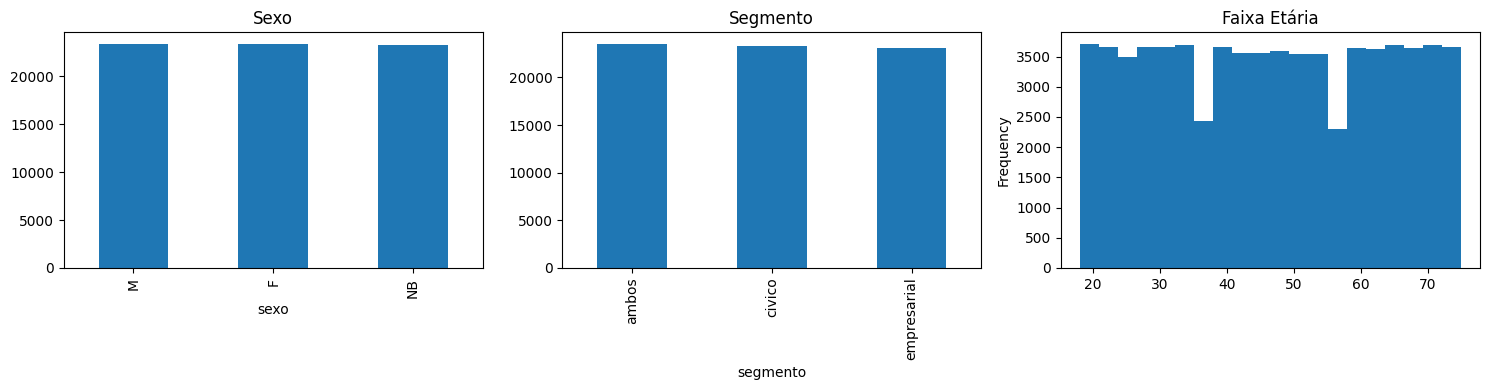

Estados cobertos: 27 / 27
regiao
PE    2675
RR    2670
SP    2664
MA    2652
PI    2643
ES    2636
RJ    2625
CE    2625
PB    2610
SE    2610
BA    2607
DF    2605
AL    2598
SC    2596
RS    2596
MS    2592
RO    2575
AC    2574
MG    2566
PR    2563
AP    2559
AM    2559
PA    2553
MT    2539
TO    2528
RN    2526
GO    2454
Name: count, dtype: int64


In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribuição por sexo
df_usuarios["sexo"].value_counts().plot(kind="bar", ax=axes[0], title="Sexo")

# Distribuição por segmento
df_usuarios["segmento"].value_counts().plot(kind="bar", ax=axes[1], title="Segmento")

# Distribuição de idade
df_usuarios["idade"].plot(kind="hist", bins=20, ax=axes[2], title="Faixa Etária")

plt.tight_layout()
plt.show()

# Cobertura regional — todos os 27 estados presentes?
print(f"Estados cobertos: {df_usuarios['regiao'].nunique()} / 27")
print(df_usuarios["regiao"].value_counts())

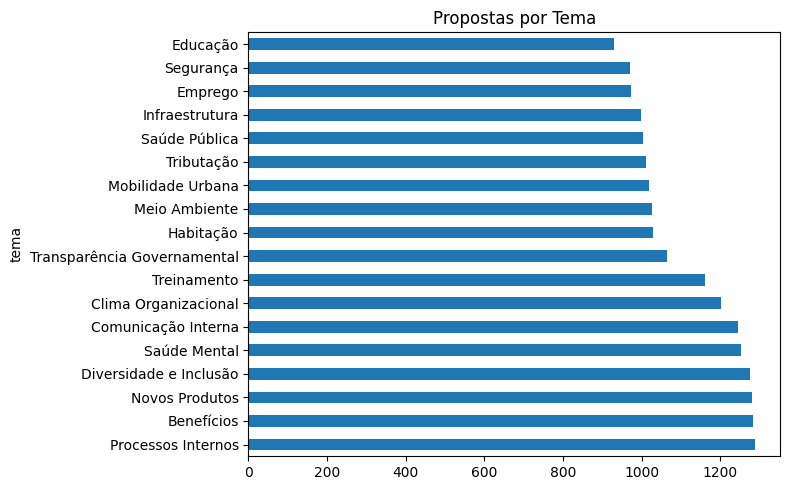

Urgentes: 10.0%


status
rejeitada     20.2
em_votacao    20.1
aberta        20.1
aprovada      19.8
fechada       19.8
Name: proportion, dtype: float64

In [18]:
# Temas mais frequentes
df_propostas["tema"].value_counts().plot(kind="barh", title="Propostas por Tema", figsize=(8,5))
plt.tight_layout()
plt.show()

# Distribuição de sentimentos — esperado: equilibrado entre os 4 tipos
df_propostas["sentimento"].value_counts(normalize=True).mul(100).round(1)

# Proporção de propostas urgentes
print(f"Urgentes: {df_propostas['urgente'].mean()*100:.1f}%")  # Esperado ~10%

# Distribuição de status
df_propostas["status"].value_counts(normalize=True).mul(100).round(1)

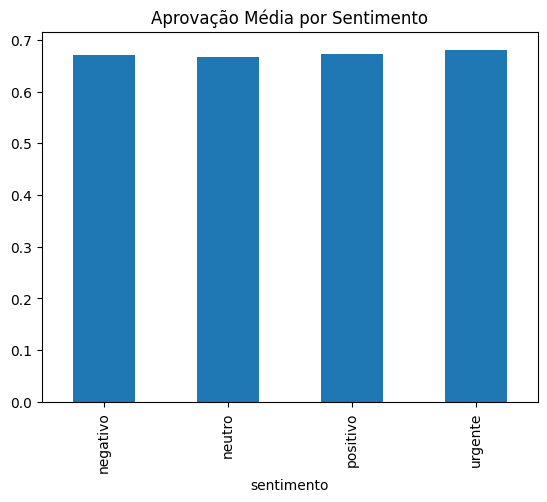

Propostas sem nenhum voto: 0


In [19]:
# Estatísticas descritivas de engajamento
df_propostas[["upvotes", "downvotes", "visualizacoes"]].describe()

# Ratio de aprovação por sentimento
df_propostas["ratio_aprovacao"] = df_propostas["upvotes"] / (df_propostas["upvotes"] + df_propostas["downvotes"] + 1)
df_propostas.groupby("sentimento")["ratio_aprovacao"].mean().plot(
    kind="bar", title="Aprovação Média por Sentimento"
)
plt.show()

# Propostas sem nenhum engajamento (possível problema)
sem_votos = df_propostas[(df_propostas["upvotes"] == 0) & (df_propostas["downvotes"] == 0)]
print(f"Propostas sem nenhum voto: {len(sem_votos)}")

count    100000.000000
mean         11.486930
std           5.192233
min           3.000000
25%           7.000000
50%          11.000000
75%          16.000000
max          20.000000
dtype: float64


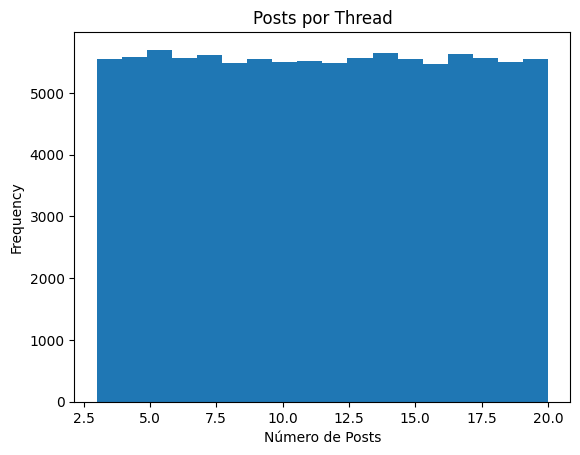

In [20]:
posts_por_thread = df_posts.groupby("thread_id").size()

print(posts_por_thread.describe())
# Esperado: entre 3 e 20 posts por thread

posts_por_thread.plot(kind="hist", bins=18, title="Posts por Thread")
plt.xlabel("Número de Posts")
plt.show()

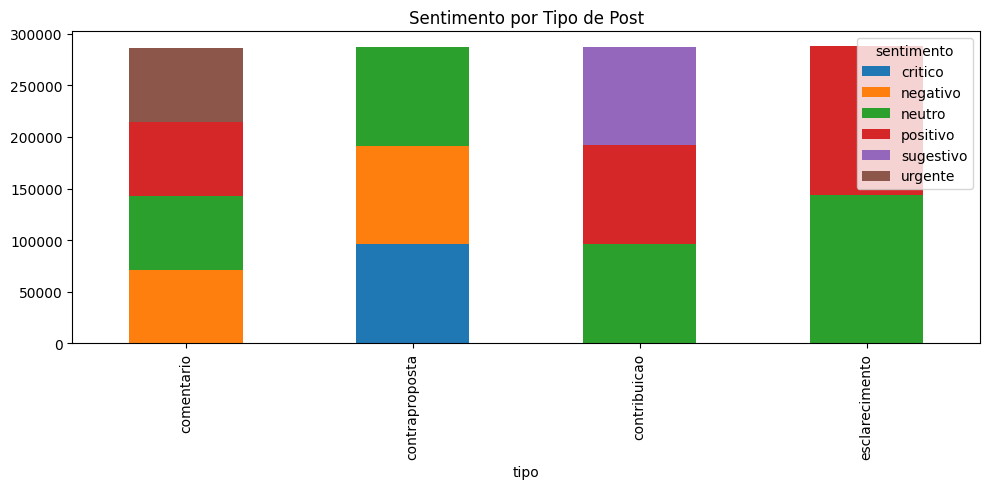

Posts moderados: 5.0%
Posts ilegais:   2.0%
Posts deletados: 2.9%


In [ ]:
# # Distribuição de sentimentos nos posts por tipo
# df_posts.groupby(["tipo", "sentimento"]).size().unstack().plot(
#     kind="bar", stacked=True, figsize=(10, 5),
#     title="Sentimento por Tipo de Post"
# )
# plt.tight_layout()
# plt.show()

# # Taxa de posts moderados e com flag ilegal
# print(f"Posts moderados: {df_posts['moderado'].mean()*100:.1f}%")   # Esperado ~5%
# print(f"Posts ilegais:   {df_posts['ilegal_flag'].mean()*100:.1f}%") # Esperado ~2%
# print(f"Posts deletados: {df_posts['deletado'].mean()*100:.1f}%")    # Esperado ~3%

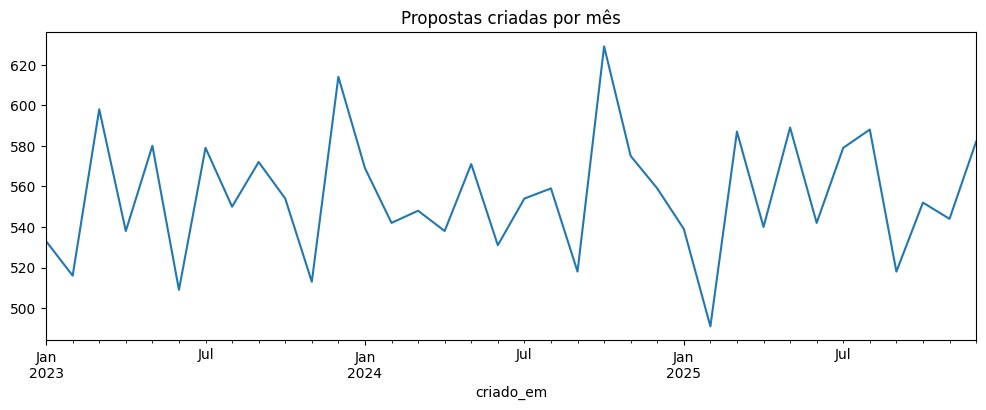

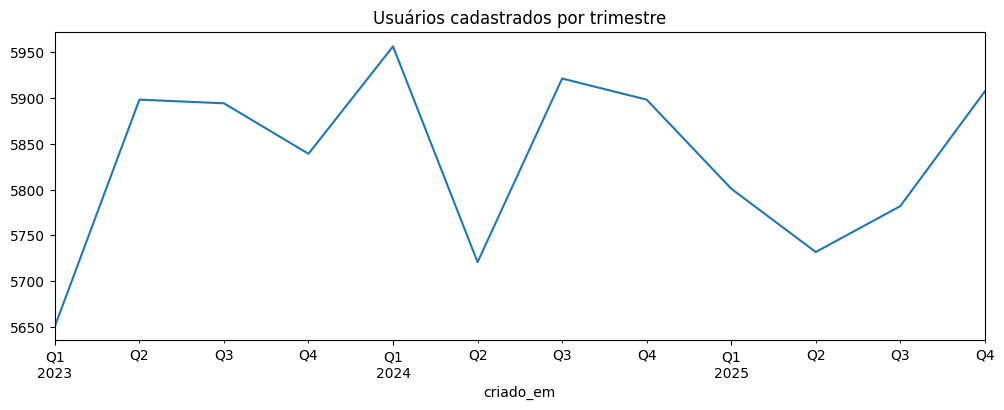

In [23]:
# Propostas por mês
df_propostas.set_index("criado_em").resample("ME")["id"].count().plot(
    title="Propostas criadas por mês", figsize=(12, 4)
)
plt.show()

# Usuários cadastrados por trimestre
df_usuarios.set_index("criado_em").resample("QE")["id"].count().plot(
    title="Usuários cadastrados por trimestre", figsize=(12, 4)
)
plt.show()

In [24]:
for nome, df in [("Usuários", df_usuarios), ("Propostas", df_propostas),
                  ("Threads", df_threads), ("Posts", df_posts)]:
    print(f"\n--- {nome} ---")
    print(f"  IDs únicos:  {df['id'].nunique()} / {len(df)}")
    print(f"  Nulos:\n{df.isnull().sum()[df.isnull().sum() > 0]}")


--- Usuários ---
  IDs únicos:  70000 / 70000
  Nulos:
setor    23301
dtype: int64

--- Propostas ---
  IDs únicos:  20000 / 20000
  Nulos:
Series([], dtype: int64)

--- Threads ---
  IDs únicos:  100000 / 100000
  Nulos:
Series([], dtype: int64)

--- Posts ---
  IDs únicos:  1148693 / 1148693
  Nulos:
Series([], dtype: int64)


In [25]:
print("=" * 40)
print("RESUMO DA BASE OPINATE")
print("=" * 40)
print(f"Usuários:   {len(df_usuarios):>10,}")
print(f"Propostas:  {len(df_propostas):>10,}")
print(f"Threads:    {len(df_threads):>10,}")
print(f"Posts:      {len(df_posts):>10,}")
# print(f"Logs:       {len(df_logs):>10,}")
print("=" * 40)
print(f"Período:    {df_propostas['criado_em'].min().date()} → {df_propostas['criado_em'].max().date()}")
print(f"Segmentos:  {df_propostas['segmento'].value_counts().to_dict()}")

RESUMO DA BASE OPINATE
Usuários:       70,000
Propostas:      20,000
Threads:       100,000
Posts:       1,148,693
Período:    2023-01-01 → 2025-12-30
Segmentos:  {'civico': 10018, 'empresarial': 9982}
